In [1]:
# Reset memoire
%reset -f 
# Affiche fenêtre separée avec interactivité
%matplotlib qt5
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
# Fermer toutes les fenetres graphiques
plt.close('all')

In [2]:
def computeFFT(signal, shift):
    # Calcul de la transformée de Fourier
    nbSamples = len(signal)
    fftSignal = np.fft.fft(signal)/nbSamples
    # On shifte pour le bilatéral
    if shift : fftSignal = np.fft.fftshift(fftSignal)
    # Calcul du module
    magfftSignal = np.abs(fftSignal);
    # Calcul de la phase
    phasefftSignal = np.angle(fftSignal);
    return magfftSignal, phasefftSignal;

def plotFFT(f, magfftSignal, phasefftSignal, label):
    # Affichage des spectres de module et de phase
    plt.figure()
    # Affichage du module
    plt.subplot(2,1,1);
    plt.plot(f, magfftSignal);
    plt.title('Spectre de module de ' + label);
    plt.xlabel('fréquence (Hz)');
    plt.ylabel('Amplitude');
    # Affichage de la phase
    plt.subplot(2,1,2);
    plt.plot(f, phasefftSignal);
    plt.title('Spectre de phase de ' + label);
    plt.xlabel('fréquence (Hz)');
    plt.ylabel('Phase');

# Calcul du spectre monolatéral (freq > 0)
def computeSingleSidedFFT(Fe, signal) :
    # Nombre d'échantillons et résolution fréquentielle
    nbSamples = len(signal);
    df = Fe/nbSamples;
    # Construction du vecteur fréquentiel
    if nbSamples % 2 == 1: # regarde si echantillon est impaire ou pas reste division entiere
        # nbSamples impair
        N = (nbSamples + 1)//2 # pour rester ccentrer sur 0
        f = np.arange(0, Fe/2 + df/2, df ) # df/2 decalage mon signal d1/2 resolution freq
    else:
        # nbSamples pair
        N = nbSamples//2
        f = np.arange(0, Fe/2, df )
    magfftSignal, phasefftSignal = computeFFT(signal, False)
    # Arrangement pour obtenir les bonnes amplitudes
    magfftSignal = np.concatenate((magfftSignal[0], 2*magfftSignal[1:N]), axis = None)
    phasefftSignal = phasefftSignal[0:N]
    return f, magfftSignal, phasefftSignal

# Calcul du spectre bilatéral (freq > 0 et < 0)
def computeDoubleSidedFFT(Fe, signal) :
    # Nombre d'échantillons et résolution fréquentielle
    nbSamples = len(signal);
    df = Fe/nbSamples;
    # Construction du vecteur fréquentiel
    if nbSamples % 2 == 1: # regarde si echantillon est impaire ou pas reste division entiere
        # nbSamples impair
        f = np.arange(-Fe/2 + df/2, Fe/2 + df/2, df ) # df/2 decalage mon signal d1/2 resolution freq
    else:
        # nbSamples pair
        f = np.arange(-Fe/2, Fe/2, df )
    # Calcul de la transformée de Fourier
    magfftSignal, phasefftSignal = computeFFT(signal, True)
    return f, magfftSignal, phasefftSignal

/var/folders/bq/rp1pp2j539s265s4psl_kbtw0000gn/T/ipykernel_11603/1892768546.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fe, note = wavfile.read('note.wav')


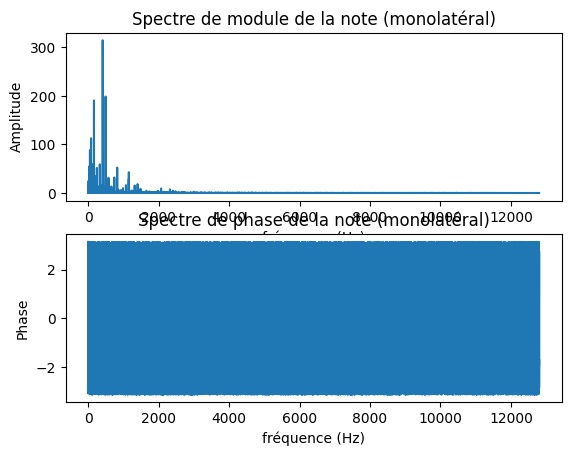

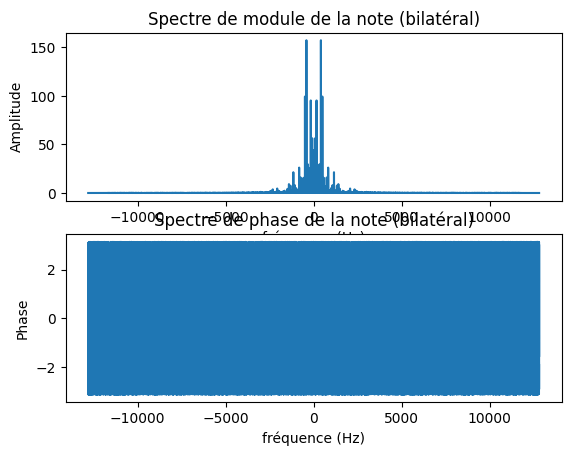

In [3]:
# Lecture du signal
Fe, note = wavfile.read('note.wav')
# Affichage spectre monolatéral note brute
f, magfftSignal, phasefftSignal = computeSingleSidedFFT(Fe, note)
plotFFT(f, magfftSignal, phasefftSignal, 'la note (monolatéral)')
# Affichage spectre bilatéral note brute
f, magfftSignal, phasefftSignal = computeDoubleSidedFFT(Fe, note)
plotFFT(f, magfftSignal, phasefftSignal, 'la note (bilatéral)')

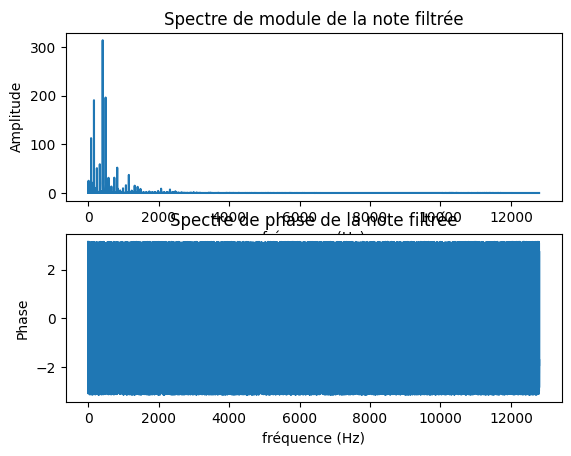

In [4]:
# Filtrage du 24.2Hz et du 50Hz et de ses harmoniques
from scipy import signal
# Supprimer le 24.2Hz
notch_freq = 24.2  # fréquence à supprimer du signal (Hz)
quality_factor = 250  # Quality factor
b, a = signal.iirnotch(notch_freq, quality_factor, Fe)
filteredNote = signal.lfilter(b, a, note) 
# Supprimer le p*50hz : boucle
for p in range(1,200) :
    notch_freq = p*50.0  # fréquence à supprimer du signal (Hz)
    b, a = signal.iirnotch(notch_freq, quality_factor, Fe)
    filteredNote = signal.lfilter(b, a, filteredNote) 
# Affichage spectre monolatéral note filtrée par rejections de fréquences
f, magfftSignal, phasefftSignal = computeSingleSidedFFT(Fe, filteredNote)
plotFFT(f, magfftSignal, phasefftSignal, 'la note filtrée')

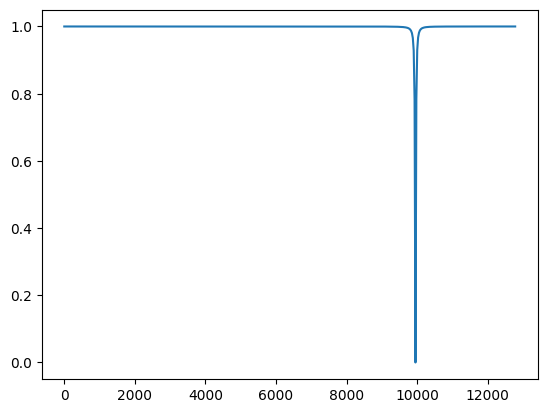

In [5]:
# Réponse en fréquence du filtre rejecteur 9950Hz (le dernier)
w, h = signal.freqz(b, a)
f = w*Fe/(2*np.pi)
plt.figure()
plt.plot(f, np.abs(h))

In [6]:
# Vision temporelle du système :
# s(n) = 0.9*s(n-1) + 0.2*s(n-2) + 0.1*e(n) - 0.6*e(n-3)
# <-FFT TFD Fourier->
# Vision fréquentielle du système :
# TZ[s(n)] = TZ[0.9*s(n-1) + 0.2*s(n-2) + 0.1*e(n) - 0.6*e(n-3)]
# TZ[s(n)] = TZ[0.9*s(n-1)] + TZ[0.2*s(n-2)] + TZ[0.1*e(n)] - TZ[0.6*e(n-3)]
# TZ[s(n)] = 0.9*TZ[s(n-1)] + 0.2*TZ[s(n-2)] + 0.1*TZ[e(n)] - 0.6*TZ[e(n-3)]***
# S(z) = 0.9*z^(-1)*S(z) + 0.2*z^(-2)*S(z) + 0.1*E(z) - 0.6*z^(-3)*E(z)
# S(z) = [0.9*z^(-1) + 0.2*z^(-2)]*S(z) + [0.1 - 0.6*z^(-3)]*E(z)
# S(z) - [0.9*z^(-1) + 0.2*z^(-2)]*S(z) = [0.1 - 0.6*z^(-3)]*E(z)
# {1 - [0.9*z^(-1) + 0.2*z^(-2)]}*S(z) = [0.1 - 0.6*z^(-3)]*E(z)
# S(z)/E(z) = [0.1 - 0.6*z^(-3)]/{1 - [0.9*z^(-1) + 0.2*z^(-2)]}
# C'est le coeff de transfert entrée sortie en fonction de la fréquence
# ***TZ[x(n-m)] = z^(-m)*X(z)

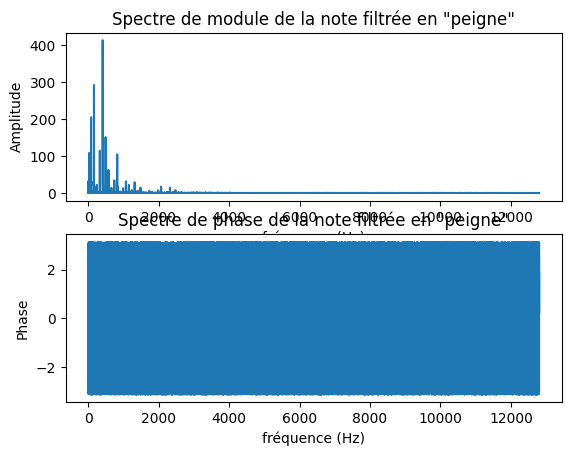

In [7]:
# Autre méthode pour enlever les 50Hz : Filtre en peigne (Comb filter)
# Définir les paramètres du filtre peigne
delay = int(Fe / 50)  # Retard pour 50 Hz
taps = delay + 1  # Nombre de coefficients du filtre
comb_filter = np.zeros(taps)
comb_filter[0] = 1
comb_filter[delay] = -1
# Appliquer le filtre
combFilteredNote = signal.lfilter(comb_filter, [1], note)
# Affichage spectre monolatéral
f, magfftSignal, phasefftSignal = computeSingleSidedFFT(Fe, combFilteredNote)
plotFFT(f, magfftSignal, phasefftSignal, 'la note filtrée en "peigne"')

In [8]:
# Comparer les trois signaux 
import sounddevice as sd
sd.play(note, Fe)
sd.wait() 
sd.play(filteredNote/np.max(np.abs(filteredNote)), Fe)
sd.wait() 
sd.play(combFilteredNote/np.max(np.abs(combFilteredNote)), Fe)
sd.wait() 